Urban Data Science & Smart Cities <br>
URSP688Y Spring 2026<br>
Instructor: Chester Harvey <br>
Urban Studies & Planning <br>
National Center for Smart Growth <br>
University of Maryland

# Abstract

This project looks at how eviction cases are distributed in space and how they relate to income levels. Because of data limitations and geocoding issues, I focus on Prince George’s County as a case study within Maryland. The goal is to understand whether eviction is randomly distributed or if it is connected to socioeconomic conditions in different areas.

At first, I tried to match eviction records to census tracts using a spatial join. However, a large number of records could not be matched, which suggests that the tract level might be too detailed for this dataset. This problem is likely related to the accuracy of geocoded addresses. To improve the reliability of the analysis, I switched to using PUMA as the spatial unit, which provided a more stable match between eviction records and geographic areas.

I then counted eviction cases for each PUMA and calculated average income based on tract-level data aggregated to the PUMA level. To explore the relationship between these variables, I created a scatter plot. I also mapped eviction counts across PUMAs to better understand their spatial distribution.

The results show that eviction cases are not evenly distributed across areas. Some PUMAs have much higher eviction counts than others, indicating spatial inequality. In addition, there is a general negative relationship between income and eviction, meaning that lower-income areas tend to have more eviction cases. These findings suggest that housing instability is closely related to both economic conditions and spatial patterns.

# Exercise03

## Problem

In the last exercise, you used tabular analyses to examine how eviction impacts tenants in Montgomery and Prince George's Counties. In this exercise, you will use more precise, address-level data to analyze evictions across the entire state through a spatial lens.

**You get to write your own research question, but with a few constraints:**
- It should be addressable with the provided eviction data
- It should require that you relate the eviction data to at least one other dataset, which you provide
- It should involve at least one form of spatial analysis (e.g., proximity, overlay, or measurement of another spatial relationship)

**Please write a short abstract (200-300 words) at the top of your exercise notebook that concisely summarizes your research question, how you addressed it, and the results of your analysis. Then provide reproducible code in cells below.**

### Bonus

Only a portion of the eviction records I'm providing for this exercise have addresses that can be geocoded (converting address strings to geographic coordinates) with a high degree of accuracy, or even at all. How could you assess bias in which records are accurately geocoded? (Hint: This will require you to define accuracy.) Can you write a Python script that evaluates whether higher- and lower-accuracy geocodes are randomly distributed across eviction records, or whether certain types of evictions are more or less likely to be geocoded well? **Please report your approach and findings in a separate paragraph and provide supporting code.**

## Data

[Exercise 3 Google Drive Folder](https://drive.google.com/drive/folders/1QLEnT5B0p43axdNkIvrdnVWpWZgaTeaT)

I'm providing you with eviction warrant data for the whole state of Maryland from 2022 through December 2024. These are from the same District Court of Maryland and Department of Housing and Community Development (DHCD) [source](https://app.powerbigov.us/view?r=eyJrIjoiYWI1Yzg0YjYtNDFkZS00MDUyLThlMDctYmE1ZjY5MGI0MWJhIiwidCI6IjdkM2I4ZDAwLWY5YmUtNDZlNy05NDYwLTRlZjJkOGY3MzE0OSJ9&pageName=ReportSection) as the data from Exercise 2, but also include street addresses. While these data are technically public, it is best practice not to store address-level data on a public GitHub repository. It is also a best practice not to commit large raw data files to Git. For both these reasons, I have shared this dataset in a [Google Drive](https://drive.google.com/drive/folders/1QLEnT5B0p43axdNkIvrdnVWpWZgaTeaT) folder to which your UMD account has been invited. You should download `md_eviction_warrants_through_2024.csv` store it in the exercise03 directory on your computer before starting to code. 

There is a `.gitignore` file in the exercise03 directory that prevents any `.csv` file from being tracked by Git. As long as you don't modify this `.gitignore`, the raw data file won't get committed, pushed to your remote fork, or included in a pull request back to the course repo.

## File Management and Submitting
To submit, please:
1. Make a new branch on your fork for this exercise.
2. Make a notebook for your exercise with your first name as an underscored suffix (e.g., `exercise02_chester.ipynb`)
    - You can either copy this notebook to work off of or start with a fresh notebook. Your choice.
4. Make commits to that branch as you work on the exercise.
5. Don't commit the eviction warrant CSV or other raw data files to Git.
    - Instead, please add any other raw data files your analysis depends on the [Exercise 3 Google Drive Folder](https://drive.google.com/drive/folders/1QLEnT5B0p43axdNkIvrdnVWpWZgaTeaT).
    - The current `.gitignore` will prevent CSV files from committing. Add additional file names/extensions as necessary.
6. Make a pull request from your branch. Ensure that the only files included in your pull request are those you intended for this exercise.

## Getting Started
To get started, here's some code I developed for geocoding the address in each eviction warrant into a geographic coordinate. You can include all or parts of this code in your own exercise, or just run this notebook to produce the `md_eviction_warrants_through_2024.geoparquet` file and import it into your own notebook to use the results.

### U.S. Census Geocoder
This geocoding process makes use of a [free geocoder provided by the US Census](https://geocoding.geo.census.gov/geocoder/). It's not the most accurate geocoder available, but it's free and fast.

### Breaking Code Into Modules
In this geocoding process, I'm demonstrating an approach to coding where you break code up into multiple modules and then import names between modules. This helps keep things tidy, allows you to easily reuse code that's generalizable between applications (e.g., the `utils.py` module here), and organize code used for more specific purposes (e.g., the `exercise03.py` and `census_geocode.py` modules).

This is exactly how packages work——modules are the basic building blocks. If you wrote an interconnected set of modules to address a certain problem space, you could publish it as a package and let others download it with conda or pip. That's how open-source software gets its start!

In [184]:
import pandas as pd
import geopandas as gpd
import utils
import exercise03
import census_geocode

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [185]:
# Load warrants and make sure zip codes are stored as strings without decimals
warrants_df = pd.read_csv('md_eviction_warrants_through_sept2025.csv')

# Ensure zip codes are stored as strings
warrants_df['TenantZipCode'] = warrants_df['TenantZipCode'].astype('Int64').astype('string')
warrants_df['EventDate'] = pd.to_datetime(warrants_df['EventDate'])
warrants_df['EvictedDate'] = pd.to_datetime(warrants_df['EvictedDate'])
warrants_df['SourceDate'] = pd.to_datetime(warrants_df['SourceDate'])

len(warrants_df) # How many warrants are we working with?

607881

In [186]:
# Rather than geocoding 600K+ addresses, can we get only the unique ones?
geocode_input_df = exercise03.prep_warrants_for_geocoding(warrants_df)

607881 warrants input
Reduced to 205620 unique addresses


In [187]:
# The Census Geocoder API can only accept up to 10K rows at a time, so we have to break
# our dataframe into chunks

# Split into dataframes with less than 10K rows each
geocode_input_dfs = utils.chunk_dataframe(geocode_input_df, 9999)

# Save each dataframe as a CSV without a header
utils.save_dfs_to_csv(geocode_input_dfs, 'geocode_inputs', header=False)

split dataframe into 21 chunks


In [188]:
# Geocode addresses with the Census Geocoder (set test=True to process only one file)
census_geocode.geocode_csvs('geocode_inputs', 'geocode_outputs', test=True)

TEST MODE: Processing only one file.
Processing file: geocode_inputs\df_0.csv


In [189]:
# Recombine outputs from geocoder into a single dataframe
geocode_output_df = exercise03.combine_census_geocoded_csvs('geocode_outputs')
len(geocode_output_df)

205620

In [190]:
# Merge geocoded address back onto the inputs with separate fields for address, city, state, and zip
geocoded_df = geocode_input_df.merge(geocode_output_df, left_index=True, right_index=True)
len(geocoded_df)

205620

In [191]:
# Use address, city, state, and zip columns to join geocodes onto original warrant records
warrants_df = warrants_df.merge(geocoded_df, on=['TenantAddress','TenantCity','TenantState','TenantZipCode'])
len(warrants_df)

607881

In [192]:
# Convert warrants into a geodataframe with points
warrants_gdf = utils.lonlat_str_to_geodataframe(warrants_df, 'match_lon_lat')

In [193]:
# What proportion of records have points?
len(warrants_gdf[warrants_gdf.lon.notnull()]) / len(warrants_gdf)

0.9507666796626313

In [194]:
# What proportion of records have exact geocode matches?
len(warrants_gdf[warrants_gdf.match_type == 'Exact']) / len(warrants_gdf)

0.551737922389415

Parquet is a file format for tabular data that efficiently stores data of many types, including a 'geoparquet' variant that stores geometries like points, lines, and polygons. You can easily save a dataframe or geodataframe to parquet with the `.to_parquet` method. The resulting file will be much smaller and load faster than more convetional formats, such as CSV or shapefile. The downside is that you won't be able to open it with Excel, ArcGIS, or other conventional desktop software.

`pip install pyarrow`

In [195]:
pip install pyarrow

Note: you may need to restart the kernel to use updated packages.


In [196]:
warrants_gdf.to_parquet('md_eviction_warrants_through_sept2025.geoparquet')

You can load a parquet file back to a dataframe with `pd.read_parquet('filename')` or a geoparquet back to a geodataframe with `gpd.read_parquet('filename')`

In [197]:
gdf = gpd.read_parquet('md_eviction_warrants_through_sept2025.geoparquet')

In [198]:
gdf.columns.tolist()

['Unnamed: 0',
 'ID',
 'EventDate',
 'EventType',
 'EventComment',
 'County',
 'Location',
 'TenantAddress',
 'TenantCity',
 'TenantState',
 'TenantZipCode',
 'CaseType',
 'CaseNumber',
 'EvictedDate',
 'Source',
 'SourceDate',
 'Year',
 'EvictionYear',
 'unique_id',
 'input_address',
 'match_status',
 'match_type',
 'match_address',
 'match_lon_lat',
 'match_tiger_line_id',
 'match_tiger_line_side',
 'lon',
 'lat',
 'geometry']

<Axes: >

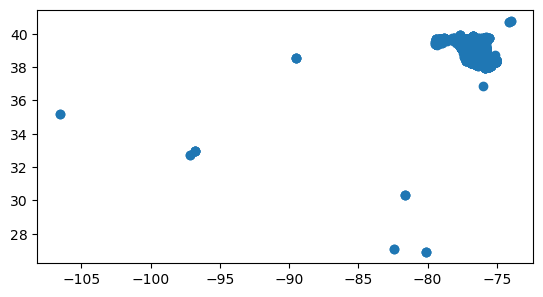

In [199]:
gdf.plot()

In [200]:
gdf['County'].value_counts()

County
Baltimore          221114
Baltimore City     110505
Prince George's    103708
Montgomery          46267
Anne Arundel        41976
Howard              18491
Harford             16850
Washington           9198
Charles              7760
Wicomico             7398
Frederick            6451
Cecil                5662
Saint Mary's         3159
Dorchester           1603
Carroll              1577
Allegany             1313
Calvert              1254
Somerset             1241
Worcester             637
Caroline              578
Queen Anne's          364
Talbot                339
Kent                  249
Garrett               187
Name: count, dtype: int64

In [201]:
pg = gdf[gdf['County'] == "Prince George's"]

In [202]:
len(pg)

103708

Load and Clean Income Data (ACS 2020-2024)

In [203]:
# Load median household income data
income = pd.read_csv('ACSDT5Y2024.B19013-Data.csv', skiprows=1)

# Keep relevant columns
income = income[['Geography', 'Estimate!!Median household income in the past 12 months (in 2024 inflation-adjusted dollars)']]

# Rename columns
income = income.rename(columns={
    'Geography': 'GEO_ID',
    'Estimate!!Median household income in the past 12 months (in 2024 inflation-adjusted dollars)': 'income'
})

# Extract tract ID
income['tract'] = income['GEO_ID'].str[-11:]

income.head()


,GEO_ID,income,tract
0,1400000US24033800102,80745,24033800102
1,1400000US24033800103,87008,24033800103
2,1400000US24033800105,109709,24033800105
3,1400000US24033800106,135119,24033800106
4,1400000US24033800108,95217,24033800108


Load Census Tract Boundaries

In [204]:
tracts = gpd.read_file('tl_2024_24_tract/tl_2024_24_tract.shp')

In [205]:
# Merge Income Data with Tracts
pg_tracts = tracts[tracts['COUNTYFP'] == '033'].copy()

pg_tracts['tract'] = pg_tracts['GEOID']

pg_tracts = pg_tracts.merge(
    income[['tract', 'income']],
    on='tract',
    how='left'
)

pg_tracts[['tract', 'income']].head()

,tract,income
0,24033807304,122625
1,24033807305,103866
2,24033807405,130680
3,24033807407,101964
4,24033803700,102125


In [206]:
pg = gdf[gdf['County'] == "Prince George's"].copy()
pg = pg.to_crs(pg_tracts.crs)
len(pg)

103708

In [207]:
# Spatial join to assign tract-level income to each warrant
pg_join = gpd.sjoin(
    pg,
    pg_tracts[['tract', 'income', 'geometry']],
    how='left',
    predicate='within'
)

pg_join.head()

,Unnamed: 0,ID,EventDate,EventType,EventComment,County,Location,TenantAddress,TenantCity,TenantState,...,match_address,match_lon_lat,match_tiger_line_id,match_tiger_line_side,lon,lat,geometry,index_right,tract,income
1,1,NaN,2025-09-30,Warrant of Restitution - Return of Service - E...,NaN,Prince George's,Hyattsville,1009 KENNEBEC STREET 1F,OXON HILL,MD,...,NaN,NaN,NaN,NaN,NaN,NaN,POINT EMPTY,NaN,NaN,NaN
4,4,NaN,2025-09-30,Warrant of Restitution - Return of Service - E...,NaN,Prince George's,Hyattsville,4105 51st Street APT 202,Bladensburg,MD,...,"1035 MISTY LYNN CIR, COCKEYSVILLE, MD, 21030","-76.61524292553,39.464536287223",650540325.0,R,-76.61524292553,39.464536287223,POINT (-76.61524 39.46453),NaN,NaN,NaN
6,6,NaN,2025-09-30,Warrant of Restitution - Return of Service - E...,NaN,Prince George's,Hyattsville,4201 RIVER ROAD 2002,COLLEGE PARK,MD,...,"7848 AMERICANA CIR, GLEN BURNIE, MD, 21060","-76.59432923921,39.138910785402",68195066.0,L,-76.59432923921,39.138910785402,POINT (-76.59433 39.13891),NaN,NaN,NaN
8,8,NaN,2025-09-30,Warrant of Restitution - Return of Service - E...,NaN,Prince George's,Hyattsville,2429 Colebrooke Drive,TEMPLE HILLS,MD,...,"301 N CHARLES ST, BALTIMORE, MD, 21201","-76.615235031494,39.292389843236",206420541.0,R,-76.615235031494,39.292389843236,POINT (-76.61524 39.29239),NaN,NaN,NaN
10,10,NaN,2025-09-30,Warrant of Restitution - Return of Service - E...,NaN,Prince George's,Hyattsville,1009 KENNEBEC STREET 2D,OXON HILL,MD,...,"301 N CHARLES ST, BALTIMORE, MD, 21201","-76.615235031494,39.292389843236",206420541.0,R,-76.615235031494,39.292389843236,POINT (-76.61524 39.29239),NaN,NaN,NaN


In [208]:
float(round(pg_join['tract'].isna().mean(), 2))

0.84

I first attempted to assign eviction points to census tracts, but the unmatched rate was very high. So I used PUMA as the final spatial unit.

Load PUMA Boundaries

In [209]:
puma = gpd.read_file('ipums_puma_2020/ipums_puma_2020.shp')

In [210]:
# Keep MD only
puma_md = puma[puma['STATEFIP'] == '24'].copy()
puma_md = puma_md.to_crs(pg.crs)

# Assign eviction points to PUMAS
pg_puma_join = gpd.sjoin(
    pg,
    puma_md[['PUMA', 'geometry']],
    how='left',
    predicate='intersects'
)

# Check matching rate
float(round(pg_puma_join['PUMA'].isna().mean(), 2))

0.05

In [211]:
# Count evictions by PUMA
evictions_by_puma = (
    pg_puma_join.groupby('PUMA')
    .size()
    .reset_index(name='eviction_count')
)

In [212]:
# Assign tracts to PUMAs
tract_puma = gpd.sjoin(
    pg_tracts,
    puma_md[['PUMA', 'geometry']],
    how='left',
    predicate='intersects'
)

In [213]:
# Aggregate income by PUMA
tract_puma['income'] = pd.to_numeric(tract_puma['income'], errors='coerce')

income_by_puma = (
    tract_puma.groupby('PUMA')['income']
    .mean()
    .reset_index()
)

Because tract-level spatial joins resulted in a high proportion of unmatched records, I aggregated both eviction counts and income to the PUMA level, which provided more stable spatial matching.

In [214]:
# Keep the seven PUMAs in Prince George's County
pg_pumas = ['01101','01102','01103','01104','01105','01106','01107']

# Ensure PUMA codes are strings with leading zeros
evictions_by_puma['PUMA'] = evictions_by_puma['PUMA'].astype(str).str.zfill(5)
income_by_puma['PUMA'] = income_by_puma['PUMA'].astype(str).str.zfill(5)

# Filter eviction data to include only PG PUMAs
evictions_pg = evictions_by_puma[
    evictions_by_puma['PUMA'].isin(pg_pumas)
].copy()

# Filter income data to include only PG PUMAs
income_pg = income_by_puma[
    income_by_puma['PUMA'].isin(pg_pumas)
].copy()

# Merge eviction counts and income by PUMA for analysis
puma_analysis = evictions_pg.merge(
    income_pg,
    on='PUMA',
    how='left'
).sort_values('PUMA')

puma_analysis

,PUMA,eviction_count,income
0,01101,2599,92871.333333
1,01102,2544,109653.288889
2,01103,2078,88110.822222
3,01104,3082,85746.276596
4,01105,947,129364.551724
5,01106,265,134971.951220
6,01107,5243,90856.372093


Visualize the relationship between income and eviction counts at the PUMA level

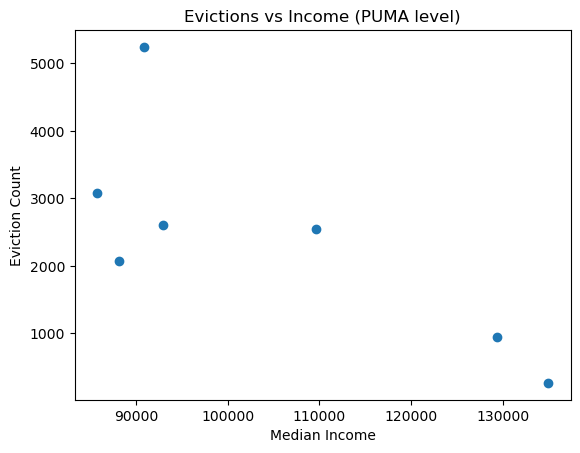

In [215]:
import matplotlib.pyplot as plt

# Create a scatter plot of eviction count vs. median income by PUMA
plt.scatter(puma_analysis['income'], puma_analysis['eviction_count'])
plt.xlabel('Median Income')
plt.ylabel('Eviction Count')
plt.title('Evictions vs Income (PUMA level)')
plt.show()

In [216]:
# This scatter plot suggests that lower-income PUMAs may experience higher eviction counts, 
# while higher-income PUMAs tend to have fewer evictions.

Map eviction counts across PUMAs in Prince George's County

In [217]:
# Merge PUMA boundaries with eviction and income data for mapping
puma_map = puma_pg.merge(
    puma_analysis,
    on='PUMA',
    how='left'
)

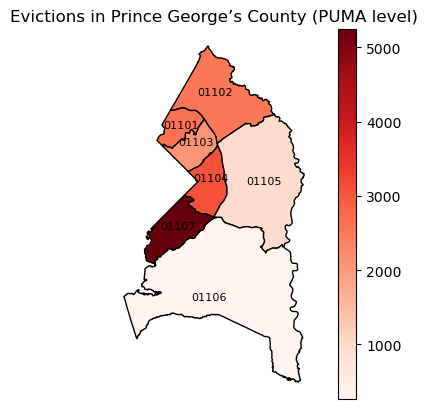

In [218]:
import matplotlib.pyplot as plt

# Plot eviction counts by PUMA with labels
ax = puma_map.plot(
    column='eviction_count',
    cmap='Reds',
    legend=True,
    edgecolor='black'
)

# Add PUMA labels to the map
for idx, row in puma_map.iterrows():
    point = row.geometry.representative_point()
    ax.text(
        point.x,
        point.y,
        row['PUMA'],
        ha='center',
        fontsize=8,
        color='black'
    )

plt.title('Evictions in Prince George’s County (PUMA level)')
plt.axis('off')
plt.show()

Assessing Bias in Geocoding Accracy

In [219]:
# In this section, I return to the original eviction point dataset before aggregation 
# to evaluate potential bias in geocoding accuracy.

In [220]:
md = gpd.read_parquet('md_eviction_warrants_through_sept2025.geoparquet')

In [221]:
tracts = tracts.to_crs(md.crs)

md_join = gpd.sjoin(
    md,
    tracts,
    how='left',
    predicate='intersects'
)

In [222]:
md_join['matched'] = md_join['GEOID'].notna()

In [223]:
md_join.groupby('County')['matched'].mean()

County
Allegany           0.957350
Anne Arundel       0.941490
Baltimore          0.952228
Baltimore City     0.950419
Calvert            0.964912
Caroline           0.961938
Carroll            0.951807
Cecil              0.945426
Charles            0.957603
Dorchester         0.948222
Frederick          0.949930
Garrett            0.957219
Harford            0.949970
Howard             0.953383
Kent               0.995984
Montgomery         0.953055
Prince George's    0.948934
Queen Anne's       0.906593
Saint Mary's       0.943970
Somerset           0.957293
Talbot             0.961652
Washington         0.953468
Wicomico           0.948364
Worcester          0.963893
Name: matched, dtype: float64

In [224]:
md['match_status'].value_counts(dropna=False)

match_status
Match       577953
No_Match     27265
Tie           2663
Name: count, dtype: int64

In [225]:
md['match_type'].value_counts(dropna=False)

match_type
Exact        335391
Non_Exact    242562
NaN           29928
Name: count, dtype: int64

In [226]:
md['high_accuracy'] = md['match_type'] == 'Exact'

In [227]:
md.groupby('County')['high_accuracy'].mean().sort_values()

County
Garrett            0.497326
Queen Anne's       0.505495
Frederick          0.538521
Charles            0.538531
Washington         0.544901
Baltimore          0.545443
Cecil              0.545920
Harford            0.546944
Dorchester         0.548347
Montgomery         0.550176
Talbot             0.554572
Anne Arundel       0.555413
Prince George's    0.556919
Caroline           0.557093
Baltimore City     0.558436
Calvert            0.560606
Somerset           0.561644
Howard             0.562111
Wicomico           0.562990
Saint Mary's       0.564103
Kent               0.570281
Allegany           0.571973
Carroll            0.575143
Worcester          0.582418
Name: high_accuracy, dtype: float64

In [228]:
md.groupby('CaseType')['high_accuracy'].mean().sort_values()

CaseType
Breach Of Lease                  0.466667
Wrongful Detainer                0.537128
Failure to Pay Rent              0.551768
Tenant Holding Over              0.556294
Breach of Lease                  0.562451
Failure To Pay Rent              0.818182
Distress / Distraint for Rent    1.000000
Name: high_accuracy, dtype: float64

To check whether geocoding accuracy is biased, I first defined high accuracy as records with an "Exact" match. I then looked at how these high-accuracy matches are distributed across counties and across different eviction case types.

The results show that geocoding accuracy is not randomly distributed. Across counties, the share of high-accuracy matches varies, which shows that some areas have better or worse geocoding results than others.The differences are even clearer across eviction case types. For example, breach of lease cases have a much lower accuracy rate (around 0.47), while some other types can be much higher, even close to 1.00. This means that certain types of eviction records are more likely to be accurately geocoded than others.

Overall, this shows that geocoding accuracy is not random and there is bias in the data. This could affect how we interpret spatial patterns of evictions.